<a href="https://www.kaggle.com/code/naomiadeniji/best-overall-performance-in-the-past-5-years?scriptVersionId=294788541" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-12-german-companies-new/Top_12_German_Companies NEW.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

df = pd.read_csv("/kaggle/input/top-12-german-companies-new/Top_12_German_Companies NEW.csv")

df["Period"] = pd.to_datetime(df["Period"], errors="coerce")

numeric_cols = ["Revenue", "Net Income", "Liabilities", "Assets", "Equity"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,Company,Period,Revenue,Net Income,Liabilities,Assets,Equity,ROA (%),ROE (%),Debt to Equity,percentage Debt to Equity
0,Volkswagen AG,2017-12-31,9750496618,5.168898e+08,21354201295,54861302788,33507101493,942.175.618,1.542.627.668,637.303.746,"0,00%"
1,Siemens AG,2017-12-31,19716237464,1.276840e+09,45009303223,75268101508,30258798286,1.696.389.282,4.219.731.382,1.487.478.214,"283,68%"
2,Allianz SE,2017-12-31,19458831198,1.600107e+09,48538978480,69583711255,21044732775,2.299.542.624,7.603.361.452,2.306.466.848,"329,65%"
3,BMW AG,2017-12-31,18808147150,9.601843e+08,35382107627,67327482638,31945375011,142.614.028,3.005.706.927,1.107.581.539,"0,00%"
4,BASF SE,2017-12-31,16895580815,1.797082e+09,28309420014,68036567115,39727147101,2.641.347.127,4.523.561.449,71.259.635,"634,80%"


In [3]:
df["Period"] = pd.to_datetime(df["Period"], errors="coerce")

num_cols = ["Revenue", "Net Income", "Assets", "Equity", "Liabilities"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[["Company", "Period"] + num_cols].head()


,Company,Period,Revenue,Net Income,Assets,Equity,Liabilities
0,Volkswagen AG,2017-12-31,9750496618,5.168898e+08,54861302788,33507101493,21354201295
1,Siemens AG,2017-12-31,19716237464,1.276840e+09,75268101508,30258798286,45009303223
2,Allianz SE,2017-12-31,19458831198,1.600107e+09,69583711255,21044732775,48538978480
3,BMW AG,2017-12-31,18808147150,9.601843e+08,67327482638,31945375011,35382107627
4,BASF SE,2017-12-31,16895580815,1.797082e+09,68036567115,39727147101,28309420014


In [4]:
df["ROA"] = df["Net Income"] / df["Assets"]
df["ROE"] = df["Net Income"] / df["Equity"]
df["Debt_to_Equity"] = df["Liabilities"] / df["Equity"]

df[["Company", "ROA", "ROE", "Debt_to_Equity"]].describe()


,ROA,ROE,Debt_to_Equity
count,384.000000,384.000000,384.000000
mean,0.022603,0.049928,1.235580
std,0.014060,0.034014,0.781592
min,0.005011,0.009805,0.219663
25%,0.013105,0.025968,0.732095
50%,0.019022,0.040042,1.034642
75%,0.028502,0.062738,1.512128
max,0.091561,0.211192,4.631348


In [5]:
latest_year = df["Period"].dt.year.max()
last_5_years = list(range(latest_year - 4, latest_year + 1))

df_5y = df[df["Period"].dt.year.isin(last_5_years)].copy()

last_5_years, df_5y["Period"].dt.year.unique()


([2020, 2021, 2022, 2023, 2024],
 array([2020, 2021, 2022, 2023, 2024], dtype=int32))

In [6]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else np.zeros(len(s))

scored = []

for year, g in df_5y.groupby(df_5y["Period"].dt.year):
    temp = g.copy()
    
    temp["Revenue_s"] = minmax(temp["Revenue"])
    temp["NetIncome_s"] = minmax(temp["Net Income"])
    temp["ROA_s"] = minmax(temp["ROA"])
    temp["ROE_s"] = minmax(temp["ROE"])
    
    # Lower debt = better
    temp["Debt_s"] = 1 - minmax(temp["Debt_to_Equity"])
    
    temp["Yearly_Score"] = temp[
        ["Revenue_s", "NetIncome_s", "ROA_s", "ROE_s", "Debt_s"]
    ].mean(axis=1)
    
    temp["Year"] = year
    scored.append(temp[["Company", "Year", "Yearly_Score"]])

scores_df = pd.concat(scored)

scores_df.sort_values(["Company", "Year"]).reset_index(drop=True)



,Company,Year,Yearly_Score
0,Allianz SE,2020,0.330240
1,Allianz SE,2020,0.299283
2,Allianz SE,2020,0.496501
3,Allianz SE,2020,0.658547
4,Allianz SE,2021,0.387375
...,...,...,...
235,Volkswagen AG,2023,0.678311
236,Volkswagen AG,2024,0.755196
237,Volkswagen AG,2024,0.277099
238,Volkswagen AG,2024,0.451084


In [7]:
five_year_perf = (
    scores_df
    .groupby("Company")["Yearly_Score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

five_year_perf.head(10)


,Company,Yearly_Score
0,BMW AG,0.485145
1,Merck KGaA,0.472280
2,Volkswagen AG,0.468535
3,Allianz SE,0.468246
4,Daimler AG,0.443813
5,BASF SE,0.430286
6,Siemens AG,0.425093
7,Deutsche Telekom AG,0.421944
8,Bayer AG,0.413469
9,Deutsche Bank AG,0.412258


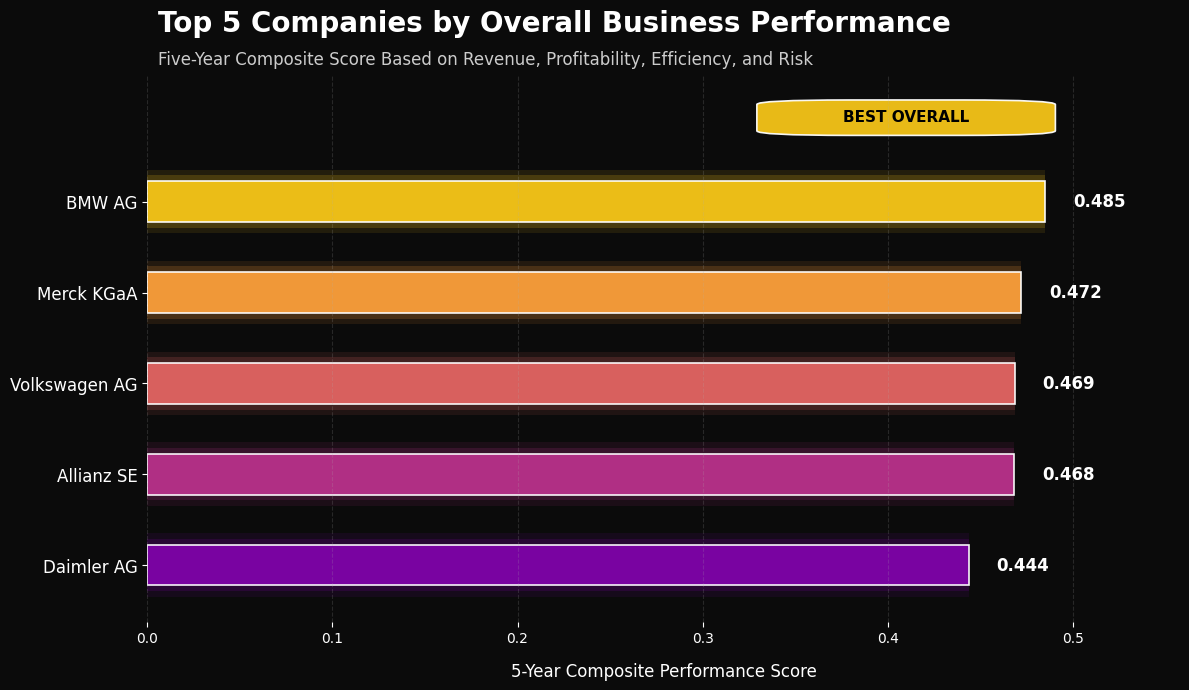

In [8]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import FancyBboxPatch

# Top 5 companies
top5 = five_year_perf.head(5).copy()
top5 = top5.sort_values("Yearly_Score")

companies = top5["Company"].values
scores = top5["Yearly_Score"].values

winner = top5.iloc[-1]["Company"]
winner_score = top5.iloc[-1]["Yearly_Score"]

#  FIGURE 
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0b0b0b")
ax.set_facecolor("#0b0b0b")

# --- COLORS ---
cmap = mpl.colormaps["plasma"]
colors = cmap(np.linspace(0.25, 0.95, len(companies)))

# Winner gets gold
colors[-1] = mpl.colors.to_rgba("#f5c518")

# DRAW BARS
for i, (company, score, color) in enumerate(zip(companies, scores, colors)):
    # Glow layers
    for alpha, h in [(0.10, 0.70), (0.18, 0.58)]:
        ax.barh(company, score, height=h, color=color, alpha=alpha, edgecolor="none")

    # Main bar
    ax.barh(
        company,
        score,
        height=0.45,
        color=color,
        edgecolor="white",
        linewidth=1.2,
        alpha=0.95
    )

    # Score label
    ax.text(
        score + 0.015,
        i,
        f"{score:.3f}",
        va="center",
        fontsize=12,
        color="white",
        weight="bold"
    )

# TITLE
ax.text(
    0.01, 1.08,
    "Top 5 Companies by Overall Business Performance",
    transform=ax.transAxes,
    fontsize=20,
    weight="bold",
    color="white"
)

ax.text(
    0.01, 1.02,
    "Five-Year Composite Score Based on Revenue, Profitability, Efficiency, and Risk",
    transform=ax.transAxes,
    fontsize=12,
    color="#cccccc"
)

#  WINNER BADGE
badge = FancyBboxPatch(
    (winner_score * 0.72, len(companies) - 0.25),
    width=winner_score * 0.25,
    height=0.35,
    boxstyle="round,pad=0.02,rounding_size=0.05",
    facecolor="#f5c518",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.95
)
ax.add_patch(badge)

ax.text(
    winner_score * 0.845,
    len(companies) - 0.07,
    "BEST OVERALL",
    ha="center",
    va="center",
    fontsize=11,
    color="black",
    weight="bold"
)

# AXES CLEANUP
ax.set_xlim(0, max(scores) * 1.15)
ax.set_xlabel("5-Year Composite Performance Score", fontsize=12, color="white", labelpad=12)

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white", labelsize=12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", alpha=0.18, linestyle="--")

plt.tight_layout()
plt.show()


Best overall business performance was assessed using a five-year composite score combining revenue, net income, ROA, ROE, and debt-to-equity. Metrics were normalized annually to ensure fair comparison and to prevent firm size or leverage from distorting results. The final score represents each company’s average performance over the last five years, emphasizing consistency, efficiency, and financial strength rather than short-term gains.

In [9]:
top_row = five_year_perf.iloc[0]
print(
    f"Best overall performing company (last 5 years): "
    f"{top_row['Company']} with a performance score of {top_row['Yearly_Score']:.3f}"
)


Best overall performing company (last 5 years): BMW AG with a performance score of 0.485
